# A/B-тестирование рекламных кампаний

## Цель исследования

Необходимо сравнить эффективность контрольной (Control) и тестовой (Test) рекламных кампаний и определить, какая из них эффективнее с точки зрения пользовательской воронки и стоимости привлечения покупки.

В ходе анализа мы:
- изучим основные показатели рекламных кампаний;
- построим воронку взаимодействия пользователя с рекламой;
- сравним конверсии между Control и Test;
- проверим статистическую значимость различий;
- сравним стоимость привлечения покупки;
- сформулируем итоговые бизнес-выводы.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from pathlib import Path
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
%matplotlib inline

## 1. Подготовка данных

Данные разделены на две группы:
- Control — контрольная рекламная кампания;
- Test — тестовая рекламная кампания.

Каждая строка содержит показатели рекламной кампании за определённый день.

Основные метрики:
- `impressions` — количество показов рекламы;
- `website_clicks` — количество кликов по рекламе;
- `searches` — количество поисковых действий;
- `view_content` — количество просмотров содержимого/товара;
- `add_to_cart` — количество добавлений товара в корзину;
- `purchase` — количество покупок;
- `spend` — рекламные расходы.

Сначала проверим структуру данных, типы столбцов, статистические характеристики и наличие пропущенных значений.

In [2]:
control = pd.read_csv(Path('ab_testing/control_group.csv'), sep=';')
test = pd.read_csv(Path('ab_testing/test_group.csv'), sep=';')
control['date'] = pd.to_datetime(control['date'], format='%d.%m.%Y')
test['date'] = pd.to_datetime(test['date'], format='%d.%m.%Y')

In [3]:
control.head()

,campaign_name,date,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
test.head()

,campaign_name,date,spend,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase
0,Test Campaign,2019-08-01,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2019-08-02,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,2019-08-03,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,2019-08-04,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,2019-08-05,2297,114295,95138,5863,2106,858,956,768


#### Примечание по предобработке:
В контрольной группе (Control) за 5 августа (строка с индексом 4) обнаружены пропуски (NaN) по всем ключевым метрикам (impressions, reach, website_clicks и т.д.), при этом расход (spend) за этот день указан. Удаление этой строки необходимо, так как отсутствие данных о показах и кликах не позволяет рассчитать воронку. В тестовой группе пропусков нет.

In [5]:
control = control.dropna()
test = test.dropna()

## 2. Сравнение основных показателей

Сравним абсолютные значения основных показателей двух рекламных кампаний

In [6]:
control[['impressions', 'website_clicks', 'searches',
         'view_content', 'add_to_cart', 'purchase']].sum()

impressions       3177233.0
website_clicks     154303.0
searches            64418.0
view_content        56370.0
add_to_cart         37700.0
purchase            15161.0
dtype: float64

In [7]:
test[['impressions', 'website_clicks', 'searches',
      'view_content', 'add_to_cart', 'purchase']].sum()

impressions       2237544
website_clicks     180970
searches            72569
view_content        55740
add_to_cart         26446
purchase            15637
dtype: int64

### Результат

Control получил больше показов и больше добавлений в корзину, однако Test получил больше кликов и покупок при меньшем количестве показов.

Поэтому для корректного сравнения эффективности необходимо перейти от абсолютных значений к относительным показателям, то есть конверсиям.

## 3. Анализ воронки

Для оценки эффективности рекламных кампаний рассмотрим последовательность действий пользователя:

**Impressions → Website Clicks → View Content → Add to Cart → Purchase**

Для каждого перехода рассчитаем конверсию относительно предыдущего этапа и сравним Control и Test.

На каждом этапе будем:
- сравнивать конверсии двух групп;
- проверять статистическую значимость различий с помощью z-теста для двух пропорций;
- определять, какая группа показывает лучший результат.

### 3.1. Показы → Клики

На первом этапе оцениваем, насколько эффективно реклама привлекает внимание пользователей и приводит их на сайт.

Используем CTR (Click-Through Rate):

$$
CTR = \frac{Website\ Clicks}{Impressions} \times 100\%
$$

После расчёта CTR проверим, является ли различие между Control и Test статистически значимым.

Так как сравниваются две пропорции, используем z-тест для двух пропорций — `proportions_ztest`.

**H₀:** CTR в Control и Test одинаков.

**H₁:** CTR в Control и Test различается.

Уровень значимости: $\alpha = 0.05$.

In [8]:
control_ctr = (
    control['website_clicks'].sum()
    / control['impressions'].sum()
    * 100
)

test_ctr = (
    test['website_clicks'].sum()
    / test['impressions'].sum()
    * 100
)

print(f'Control CTR: {control_ctr}%')
print(f'Test CTR: {test_ctr}%')

Control CTR: 4.856521381969784%
Test CTR: 8.087885646047631%


#### Результат

Control CTR = **4.86%**

Test CTR = **8.09%**

Test показывает более высокий CTR. Далее проверим, является ли это различие статистически значимым.

In [9]:
clicks = [
    control['website_clicks'].sum(),
    test['website_clicks'].sum()
]
impressions = [
    control['impressions'].sum(),
    test['impressions'].sum()
]

z_stat_1, p_val_1 = proportions_ztest(
    count=clicks,
    nobs=impressions
)
print(f'Z-stat_1:', z_stat_1)
print('P-value: ', p_val_1)

Z-stat_1: -153.6301966248054
P-value:  0.0


CTR тестовой группы (8.09%) статистически значимо выше контрольной (4.86%, $p < 0.05$). Тестовый креатив/таргетинг значительно лучше привлекает внимание пользователей на этапе показа рекламы.

### 3.2. Клики → Просмотр товара

Оценим, какая доля пользователей, кликнувших по рекламе, действительно просмотрела содержимое товара.

Конверсия рассчитывается как:

$$
Conversion = \frac{View\ Content}{Website\ Clicks} \times 100\%
$$

$H₀:$ конверсия в Control и Test одинаковая.

$H₁:$ конверсия в Control и Test различается.

Для проверки используем z-тест для двух пропорций.

In [10]:
control_view_conversion = (
    control['view_content'].sum()
    / control['website_clicks'].sum()
    * 100
)

test_view_conversion = (
    test['view_content'].sum()
    / test['website_clicks'].sum()
    * 100
)

print('Control: ', control_view_conversion, '%')
print('Test: ', test_view_conversion, '%')

Control:  36.532018172038136 %
Test:  30.800685196441396 %


In [11]:
view_content = [
    control['view_content'].sum(),
    test['view_content'].sum()
]

clicks = [
    control['website_clicks'].sum(),
    test['website_clicks'].sum()
]

z_stat_2, p_val_2 = proportions_ztest(
    count=view_content,
    nobs=clicks
)

print('Z-stat:', z_stat_2)
print('p-value:', p_val_2)

Z-stat: 35.06001819358583
p-value: 2.7436455012390667e-269


На этапе перехода с клика на просмотр товара контрольная группа показывает более высокую конверсию (36.53% против 30.80%, $p < 10^{-5}$). Это свидетельствует о том, что кликавшие по тестовой рекламе пользователи реже доходят до просмотра товара (возможно, релевантность посадочной страницы у Test ниже или привлекается менее целевой трафик).

### 3.3. Просмотр товара → Добавление в корзину

Оценим, какая доля пользователей, просмотревших товар, добавила его в корзину.

Конверсия рассчитывается как:

$$
Conversion = \frac{Add\ To\ Cart}{View\ Content} \times 100\%
$$

$H₀:$ конверсия в Control и Test одинаковая.

$H₁:$ конверсия в Control и Test различается.

Для проверки используем z-тест для двух пропорций.

In [12]:
control_cart_conversion = (
    control['add_to_cart'].sum()
    / control['view_content'].sum()
    * 100
)

test_cart_conversion = (
    test['add_to_cart'].sum()
    / test['view_content'].sum()
    * 100
)

print('Control: ', control_cart_conversion, '%')
print('Test: ', test_cart_conversion, '%')

Control:  66.87954585772574 %
Test:  47.445281664872624 %


In [13]:
add_to_cart = [
    control['add_to_cart'].sum(),
    test['add_to_cart'].sum()
]

z_stat_3, p_val_3 = proportions_ztest(
    count=add_to_cart,
    nobs=view_content
)

print('Z-stat:', z_stat_3)
print('p-value:', p_val_3)

Z-stat: 65.75901375279913
p-value: 0.0


Контрольная группа существенно превосходит тестовую по конверсии из просмотра в добавление в корзину (66.88% против 47.45%, $p < 0.05$). Пользователи из контрольной группы проявляют более высокий покупательский интент на этапе выбора товара.

### 3.4. Добавление в корзину → Покупка


In [14]:
control_purchase_conversion = (
    control['purchase'].sum()
    / control['add_to_cart'].sum()
    * 100
)

test_purchase_conversion = (
    test['purchase'].sum()
    / test['add_to_cart'].sum()
    * 100
)
print(control_purchase_conversion, '%')
print(test_purchase_conversion, '%')

40.214854111405835 %
59.12803448536641 %


У тестовой кампании конверсия добавления в корзину/покупки больше на 19 процентных пунктов. Проверим является ли эта разница статистически значимой.

In [15]:
purchases = [
    control['purchase'].sum(),
    test['purchase'].sum()
]

z_stat_4, p_val_4 = proportions_ztest(count=purchases, nobs=add_to_cart)

print('Z-stat:', z_stat_4)
print('p-value:', p_val_4)

Z-stat: -47.19585656254958
p-value: 0.0


На финальном шаге воронки тестовая группа показывает компенсационный рост: 59.13% пользователей, добавивших товар в корзину, совершают покупку (против 40.21% в Control, $p < 0.05$).

### 3.5. Показы — Покупки
Выясним какая доля пользователей, которым показалась реклама, дошла до покупки.

In [16]:
z_stat_5, p_val_5 = proportions_ztest(
    count=purchases,
    nobs=impressions
)

print('Z-stat:', z_stat_5)
print('p-value:', p_val_5)

Z-stat: -33.77499922226043
p-value: 4.59330633997262e-250


### 3.6. Оценка эффективности расходов (Траты → Покупки)

Проанализируем конверсию затрат на рекламу в совершенные покупки (отношение количества покупок к общей сумме трат).

* **$H_0$:** Эффективность конвертации рекламных расходов в покупки одинакова для контрольной и тестовой групп ($\mu_{control} = \mu_{test}$).
* **$H_1$:** Эффективность конвертации рекламных расходов в покупки различается ($\mu_{control} \neq \mu_{test}$).

In [17]:
control_spend_conversion = (
    control['purchase'].sum()
    / control['spend'].sum()
    * 100
)

test_spend_conversion = (
    test['purchase'].sum()
    / test['spend'].sum()
    * 100
)
print(control_spend_conversion, '%')
print(test_spend_conversion, '%')

22.68999371426861 %
20.336315871612133 %


In [18]:
spend = [
    control['spend'].sum(),
    test['spend'].sum()
]

z_stat_6, p_val_6 = proportions_ztest(count=purchases, nobs=spend)
print('Z-stat:', z_stat_6)
print('p-value:', p_val_6)

Z-stat: 10.84542364138785
p-value: 2.0966226643017476e-27


In [19]:
results = pd.DataFrame({
    'Metric': [
        'CTR',
        'Click → View',
        'View → Cart',
        'Cart → Purchase',
        'Impression → Purchase',
        'CPA'
    ],
    'Control': [
        control_ctr,
        control_view_conversion,
        control_cart_conversion,
        control_purchase_conversion,
        control['purchase'].sum() / control['impressions'].sum() * 100,
        control['spend'].sum() / control['purchase'].sum()
    ],
    'Test': [
        test_ctr,
        test_view_conversion,
        test_cart_conversion,
        test_purchase_conversion,
        test['purchase'].sum() / test['impressions'].sum() * 100,
        test['spend'].sum() / test['purchase'].sum()
    ]
})

results

,Metric,Control,Test
0,CTR,4.856521,8.087886
1,Click → View,36.532018,30.800685
2,View → Cart,66.879546,47.445282
3,Cart → Purchase,40.214854,59.128034
4,Impression → Purchase,0.477176,0.698847
5,CPA,4.407229,4.917312


In [20]:
results['p-value'] = [
    p_val_1,
    p_val_2,
    p_val_3,
    p_val_4,
    p_val_5,
    p_val_6
]

results['p-value'] = results['p-value'].apply(lambda x: f"{x:.4f}" if x > 0.0001 else "< 0.0001")

results

,Metric,Control,Test,p-value
0,CTR,4.856521,8.087886,< 0.0001
1,Click → View,36.532018,30.800685,< 0.0001
2,View → Cart,66.879546,47.445282,< 0.0001
3,Cart → Purchase,40.214854,59.128034,< 0.0001
4,Impression → Purchase,0.477176,0.698847,< 0.0001
5,CPA,4.407229,4.917312,< 0.0001


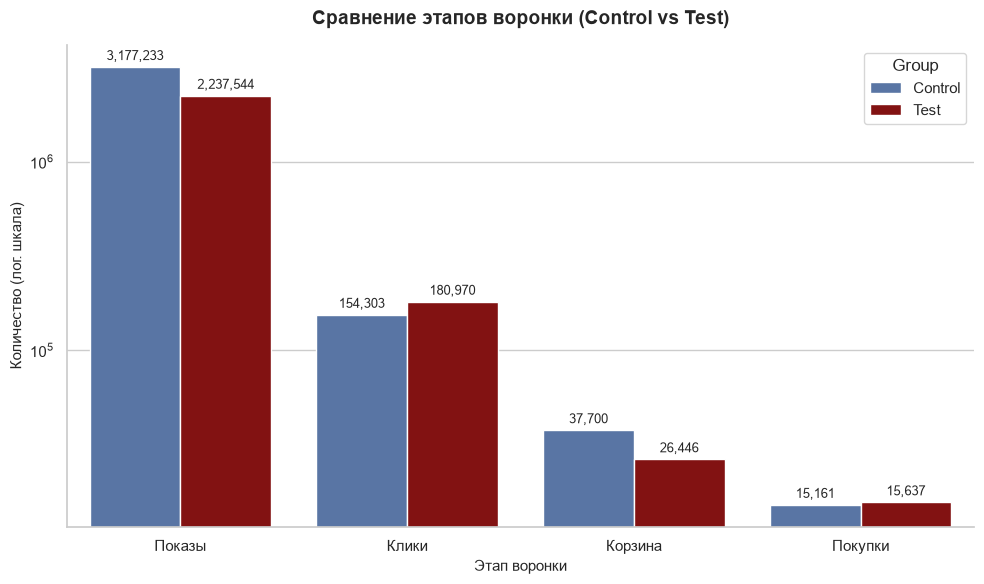

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stages = ['impressions', 'website_clicks', 'add_to_cart', 'purchase']

control_sums = control[stages].sum()
test_sums = test[stages].sum()

df_plot = pd.DataFrame({
    'Stage': ['Показы', 'Клики', 'Корзина', 'Покупки'],
    'Control': control_sums.values,
    'Test': test_sums.values
})

df_melted = df_plot.melt(id_vars='Stage', var_name='Group', value_name='Count')

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_melted,
    x='Stage',
    y='Count',
    hue='Group',
    palette=['#4C72B0', '#940000']
)

plt.title('Сравнение этапов воронки (Control vs Test)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Этап воронки', fontsize=11)
plt.ylabel('Количество (лог. шкала)', fontsize=11)
plt.yscale('log')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height):,}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

sns.despine()
plt.tight_layout()
plt.show()

# Заключение
В ходе A/B-тестирования было выявлено, что тестовая кампания значительно увеличивает CTR: 8.09% против 4.86% в контрольной группе. При этом на этапах «клик → просмотр товара» и «просмотр → добавление в корзину» Control показывает более высокую конверсию. Однако Test значительно лучше конвертирует добавления в корзину в покупки: 59.13% против 40.21%. В результате итоговая конверсия из показа в покупку у Test выше: 0.699% против 0.477%, и различие статистически значимо. При этом стоимость привлечения одной покупки у Test выше: 4.92 против 4.53 у Control, то есть примерно на 8.6%.

## 4. Итоговые выводы и рекомендации

1. **Воронка конверсии:**
   - **Test-кампания** выигрывает на этапе привлекательности рекламы (CTR **8.09%** vs **4.86%**) и на шаге принятия решения о покупке из корзины (**59.13%** vs **40.21%**).
   - **Control-кампания** лучше удерживает пользователей внутри сайта: выше конверсия из клика в просмотр (**36.53%** vs **30.80%**) и из просмотра в корзину (**66.88%** vs **47.45%**).
   - Суммарная конверсия из показа в покупку (Impression → Purchase) выше у **Test** (**0.70%** vs **0.48%**).

2. **Экономическая эффективность (CPA):**
   - Стоимость привлечения одной покупки (CPA) в тестовой группе оказалась **выше** (**4.92** у.е. против **4.53** у.e. в Control).
   - Причина: несмотря на высокую суммарную конверсию, тестовая кампания потратила больше бюджета на единицу конверсии из-за просадки на этапах просмотра и добавления в корзину.

3. **Рекомендация для бизнеса:**
   - **Не раскатывать Test-кампанию в текущем виде на полный бюджет.**
   - Провести доработку: взять кликабельные креативы/заголовки из **Test** (обеспечившие высокий CTR), но оптимизировать посадочную страницу и продуктовый путь под опыт **Control** (чтобы не терять пользователей на этапе просмотра и добавления в корзину).